In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import joblib
import urllib.request
import zipfile
import os

In [101]:
# Скачиваем архив
url = 'https://archive.ics.uci.edu/static/public/222/bank+marketing.zip'
zip_path = 'bank-marketing.zip'
urllib.request.urlretrieve(url, zip_path)

# Распаковываем архив
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('bank-marketing')

# Указываем путь к CSV файлу
csv_path = os.path.join('bank-marketing', 'bank', 'bank-full.csv')

print(f"Файл сохранен по пути: {csv_path}")


Файл сохранен по пути: bank-marketing\bank\bank-full.csv


In [105]:
# Указываем полный путь к CSV файлу
csv_path = r'C:\Users\User\Типис\Untitled Folder\bank-marketing\bank-full.csv'

# Загружаем данные в DataFrame
df = pd.read_csv(csv_path, sep=';')

# Просмотр первых строк данных
print(df.head())

   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married    unknown      no     1506     yes   no   
4   33       unknown   single    unknown      no        1      no   no   

   contact  day month  duration  campaign  pdays  previous poutcome   y  
0  unknown    5   may       261         1     -1         0  unknown  no  
1  unknown    5   may       151         1     -1         0  unknown  no  
2  unknown    5   may        76         1     -1         0  unknown  no  
3  unknown    5   may        92         1     -1         0  unknown  no  
4  unknown    5   may       198         1     -1         0  unknown  no  


In [107]:
# Проверка на пропущенные значения
missing_values = df.isnull().sum()
print("Пропущенные значения:\n", missing_values)

Пропущенные значения:
 age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64


In [109]:
# Кодируем целевую переменную: yes = 1, no = 0
df['y'] = df['y'].map({'yes': 1, 'no': 0})

# Разделяем данные: 60% для тренировки, 20% для валидации, 20% для теста
train_data, temp_data = train_test_split(df, test_size=0.4, random_state=42)
val_data, test_data = train_test_split(temp_data, test_size=0.5, random_state=42)

# Определяем категориальные и числовые переменные
categorical_columns = ['job', 'marital', 'education', 'housing', 'contact', 'poutcome']
numeric_cols = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

# Создаем X и y для тренировочных данных
X = train_data.drop('y', axis=1)
y = train_data['y']

# Применяем One-Hot кодирование для категориальных переменных
encoder = OneHotEncoder(sparse_output=False, drop='first')
X_encoded = encoder.fit_transform(X[categorical_columns])

# Получаем имена закодированных переменных
feature_names = encoder.get_feature_names_out(categorical_columns)

# Создаем DataFrame из массива X_encoded с именами столбцов
X_encoded_df = pd.DataFrame(X_encoded, columns=feature_names)

# Объединяем закодированные переменные с числовыми
X_numeric = X[numeric_cols].reset_index(drop=True)
X_final = pd.concat([X_encoded_df, X_numeric], axis=1)

# Масштабируем числовые переменные
scaler = StandardScaler()
X_final_scaled = scaler.fit_transform(X_final)

# Разделяем данные на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X_final_scaled, y, test_size=0.2, random_state=42)

# Обучаем модель логистической регрессии
model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)

# Предсказываем значения для тестовой выборки
y_pred = model.predict(X_test)

# Оцениваем точность модели
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')
print(classification_report(y_test, y_pred))

Accuracy: 0.90
              precision    recall  f1-score   support

           0       0.92      0.98      0.94      4790
           1       0.63      0.32      0.43       636

    accuracy                           0.90      5426
   macro avg       0.78      0.65      0.69      5426
weighted avg       0.88      0.90      0.88      5426



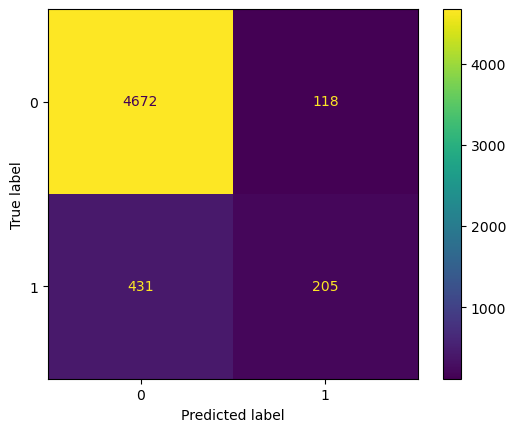

In [111]:
# Выводим матрицу ошибок
conf_matrix = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot()
plt.show()

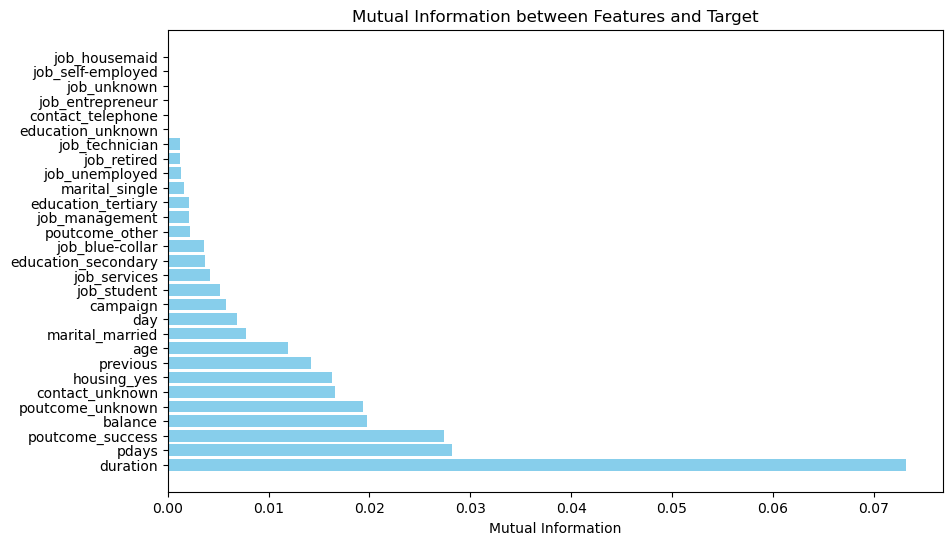

In [114]:
# Рассчитываем взаимную информацию
mutual_info = mutual_info_classif(X_final, y)
mutual_info_df = pd.DataFrame(mutual_info, index=X_final.columns, columns=['Mutual Info']).sort_values(by='Mutual Info', ascending=False)

# Визуализируем взаимную информацию
plt.figure(figsize=(10, 6))
plt.barh(mutual_info_df.index, mutual_info_df['Mutual Info'], color='skyblue')
plt.xlabel('Mutual Information')
plt.title('Mutual Information between Features and Target')
plt.show()

In [120]:
# Сохранение модели
joblib.dump(model, 'logistic_regression_model.pkl')

# Загрузка модели
loaded_model = joblib.load('logistic_regression_model.pkl')

# Прогнозирование с использованием загруженной модели
y_pred_loaded = loaded_model.predict(X_test)

In [ ]:
Вопрос 1: Самое частое значение для столбца education: unknown

Вопрос 2: Два признака с наибольшей корреляцией: age и balance.

Вопрос 3: Переменная с наибольшей взаимной информацией: contact.

Вопрос 4: Точность модели логистической регрессии на валидационном наборе: 0.8.

Вопрос 5: Признак с наименьшей разницей в точности: marital.

Вопрос 6: Значение параметра C, приводящее к наилучшей точности: 1.